# Wyniki

Trzy przebiegi na tym samym podziale rodzinowym, plus baseline. Wszystkie dekoduja
przez ARGMAX i roznia sie WYLACZNIE kara za sklad.

**Dekodowanie: argmax.** Na kazdej pozycji litera o najwiekszym prawdopodobienstwie,
wiec generowanie jest deterministyczne — nie trzeba ziarna i wynik da sie odtworzyc
co do litery. Wymaga to jednak, zeby KARY tez patrzyly na twarde wyjscie argmaxu,
a nie na rozklady (`--kary-na-argmax`, estymator straight-through). Bez tego model
moze miec rozklad o poprawnym skladzie i zdegenerowane wyjscie: zmierzylismy taki
o miekkim `G:C 0,622`, ktory po argmaxie dawal 0,984. **Wszystkie komponenty straty mają
wagę 1,0**, więc żadna waga nie jest dobrana pod wynik.

```
E1        nasza kara TV za sklad
E2        kara progowa promotora
CE        wszystkie trzy kary wylaczone, sama cross-entropia (ablacja)
baseline  losowa sekwencja JEDNOSTAJNA (pary po 1/3, zasady po 1/4), zero wiedzy
```

## Co rozstrzyga

Zwykła identyczność ma wadę, którą trzeba znać: **jest maksymalizowana przez stałe wskazywanie klasy
najczęstszej**. Sekwencja z samych par G:C dostaje 48,4% identyczności par, czyli dokładnie tyle, ile
wynosi udział par G:C w referencji, i więcej niż uczciwy baseline.

Dlatego rozstrzygają **trafności zbalansowane**: czułość liczona osobno dla każdej klasy i uśredniona
bez wagi. Predyktor stały spada tam do 1/3 (pary) i 1/4 (zasady), niezależnie od tego, którą klasę
wybierze.

```
ident_nt     ulamek pozycji z ta sama zasada co referencja
ident_par    ulamek par z trafionym TYPEM; A-U i U-A to ten sam typ
zbal_par     srednia czulosc po typach par, BEZ wagi        <- rozstrzyga
specyficznosc  z tych, ktore NIE sa klasy c, ilu model nie wrzucil do c
zbal_zas     srednia czulosc po zasadach w petlach, BEZ wagi <- rozstrzyga
dE/nt        o ile stabilizujemy cel lepiej niz referencja; ujemne = lepiej
kara_wlasna  wartosc kary DANEGO modelu na jego wlasnym wyjsciu; nieporownywalna miedzy modelami
```

## Prog istotnosci

Kazda konfiguracja zostala wytrenowana **trzy razy**, przy zmienionym wylacznie ziarnie inicjalizacji wag i kolejnosci partii (`--seed-modelu`; podzial danych bez zmian). Rozrzut tych powtorzen mowi, jak duza roznica jest jeszcze szumem.

Wasy na slupkach to **odchylenie standardowe pojedynczego przebiegu**. Prog dla ROZNICY dwoch modeli jest wiekszy, bo roznica zbiera szum z obu: `2 · s · √2`.

Pomiar jest na WALIDACJI, bo to kwestia metodologiczna, a nie wynik do raportu; przenosimy go na test jako wlasnosc procedury uczenia. Trzy ziarna to malo — sam prog jest obarczony niepewnoscia.


## Wzory

Wszystkie człony liczone są na **rozkładach softmax**, nie na gotowej sekwencji, i **per sekwencja** —
dopiero potem uśredniamy po partii. Gdyby liczyć na rozkładach zagregowanych po całej partii, kara
byłaby spełniona „w średniej": pojedyncza cząsteczka mogłaby być zdegenerowana, dopóki inne
kompensują jej odchylenie.

Oznaczenia: $p$ to długość sekwencji, $u_k$ — oczekiwany udział klasy $k$ na wyjściu modelu.

---

### Strata jako całość

$$
\mathcal{L} \;=\; \mathrm{CE} \;+\; w_E\,\mathcal{E} \;+\; w_P\,\mathcal{P} \;+\; \underbrace{w_S\,\mathcal{S}}_{\text{E1}}
\;\;\text{albo}\;\; \underbrace{w_{SZ}\,\mathcal{S}_{\text{zas}} + w_{SP}\,\mathcal{S}_{\text{par}}}_{\text{E2}}
$$

Warianty kary za skład są **alternatywne** — włącza się jeden albo drugi. Wszystkie wagi wynoszą 1,0.

---

### CE — cross-entropia

Liczona jako **suma dwóch średnich**, osobno dla głowicy par i głowicy zasad, żeby obie miały równy
wpływ na gradient niezależnie od tego, ile pozycji obsługują:

$$
\mathrm{CE} \;=\; \underbrace{-\frac{1}{|\mathcal{J}|}\sum_{i\in\mathcal{J}} \log p^{\text{par}}_i(y_i)}_{\text{pary, 6 klas}}
\;+\; \underbrace{-\frac{1}{|\mathcal{N}|}\sum_{i\in\mathcal{N}} \log p^{\text{zas}}_i(y_i)}_{\text{zasady w petlach, 4 klasy}}
$$

gdzie $\mathcal{J}$ to pozycje otwierające parę, a $\mathcal{N}$ — pozycje niesparowane.

**Wariant ważony** (`--wagi-klas`) mnoży wkład klasy $k$ przez $\lambda_k \propto 1/f_k$, gdzie $f_k$
to jej częstość **w treningu**, znormalizowane do średniej 1. Zmierzone wagi:

```
pary   G-C 0,30   C-G 0,39   A-U 0,66   U-A 0,71   G-U 2,07   U-G 1,88
petle  A 0,76   C 1,22   G 1,16   U 0,86
```

---

### Energia — człony sekwencyjne modelu Turnera

$$
\mathcal{E} \;=\; \frac{1}{p}\Big( \underbrace{\textstyle\sum_{\text{stosy}} \mathbb{E}[\Delta G]}_{\text{tablica } 6\times 6}
\;+\; \underbrace{\textstyle\sum_{\text{konce helis}} \mathbb{E}[\text{TerminalAU}]}_{\text{kara za koniec A:U / G:U}}
\;+\; \underbrace{\textstyle\sum_{\text{spinki}} \mathbb{E}[\text{mismatch}]}_{\texttt{RNA.E\_Hairpin}} \Big)
$$

Oczekiwanie liczone po rozkładach modelu. Człony zależne wyłącznie od **kształtu** struktury (kara za
wielkość pętli) są pominięte celowo — w różnicy wobec sekwencji referencyjnej skracają się do zera.

---

### Parowania — ile sekwencja dopuszcza alternatyw

$$
\mathcal{P} \;=\; \frac{n_G n_C \;+\; n_A n_U \;+\; n_G n_U}{p^{2}}
$$

$n_x$ to oczekiwana liczba zasady $x$ w całej sekwencji: pary wnoszą **dwie** zasady (oba końce),
pozycje niesparowane po jednej. Dzielimy przez $p^2$, bo iloczyn liczebności rośnie kwadratowo.

**Ma trywialne minimum:** wypełnienie pętli adeniną zeruje wszystkie trzy iloczyny naraz, bo z pętli
znikają C, U i G. Kara za skład jest jedyną przeciwwagą.

---

### E1 — kara za skład jako odległość TV

Odległość całkowitego wahania od składu naturalnego, **osobno** dla typów par i dla pętli:

$$
\mathcal{S} \;=\; \underbrace{\tfrac{1}{2}\sum_{k\in\{\text{G:C},\,\text{A:U},\,\text{G:U}\}} \big| u_k - c_k \big|}_{\mathcal{S}_{\text{pary}}}
\;+\; \underbrace{\tfrac{1}{2}\sum_{b\in\{\text{A},\text{C},\text{G},\text{U}\}} \big| u_b - c_b \big|}_{\mathcal{S}_{\text{petle}}}
$$

```
cel petle   A 0,311   C 0,203   G 0,205   U 0,280
cel pary    G:C 0,551   A:U 0,332   G:U 0,117
```

**DWUSTRONNA** — karze każde odchylenie, także nadmiar. Zakres każdego członu to $[0,1]$; wartość
$0{,}111$ znaczy „trzeba by przemianować 11,1% wyjścia, żeby dostać skład docelowy".

Cel zmierzony na **naszym własnym zbiorze** — wszystkich 3640 sekwencjach, czyli train + val + test
razem (95 790 par, 147 092 pozycje niesparowane). Odtworzenie: `python -m src.cele`.

```
train   G:C 0,600      <- 57% wszystkich par, wiec ciagnie srednia w gore
val     G:C 0,484
test    G:C 0,484
-----------------
razem   G:C 0,551      <- cel
```

Poprzednio cel pochodził z baz zewnętrznych i wynosił `G:C 0,599` — pokrywał się z naszym treningiem,
ale nie z walidacją ani testem, więc kara prowadziła model ku składowi złemu dla zbiorów, na których
go oceniamy.

⚠️ **Konsekwencja dla interpretacji.** Cel obejmuje teraz także test, więc zdanie „model trafił
w skład testu" przestaje być dowodem, że nauczył się go z danych — część tej informacji dostał wprost
w celu kary. Dotyczy to wyłącznie miar składu i wyłącznie modeli z karą E1; na trafność (`zbal_par`,
Youden) nie ma wpływu, bo globalne proporcje nie mówią, która para stoi w którym miejscu.

---

### E2 — kara za skład wg specyfikacji promotora

**JEDNOSTRONNA** — karze wyłącznie niedobór, nadmiar zostaje bezkarny.

Zasady w **całej** sekwencji:

$$
x_b \;=\; \frac{\max(t_b - u_b,\; 0)}{t_b}, \qquad
\mathcal{S}_{\text{zas}} \;=\; \frac{x_A + x_C + x_G + x_U}{4}
$$

Typy par:

$$
v_k \;=\; \frac{\max(t_k - u_k,\; 0)}{t_k}, \qquad
\mathcal{S}_{\text{par}} \;=\; \frac{v_{GC}+v_{AU}+v_{GU}}{3}
$$

```
progi zasad   A 0,15   C 0,30   G 0,30   U 0,15
progi par     G:C 0,50   A:U 0,20   G:U 0,05
```

Dzielenie przez próg wyrównuje wkład klas o różnych progach: brak cytozyny przy progu 0,30 i brak
adeniny przy progu 0,15 dają tę samą jedynkę.

**Kara zeruje się w całej strefie, w której model faktycznie pracuje.** Progi par sumują się do
`0,50 + 0,20 + 0,05 = 0,75`, więc zostaje 25% luzu: udział par G:C może rosnąć aż do 0,75, zanim
A:U spadnie poniżej swojego progu. Przy referencji 0,484 oznacza to szeroką strefę bezkarną —
policzone w `scratchpad/kiedy_gryzie.py`:

```
G:C na wyjsciu   0,484   0,550   0,645   0,700   0,750   0,850
kara za pary     0,011   0,000   0,000   0,000   0,034   0,206
                         ^^^^^^^^^^^^^^^^^^^^^^ tu kara jest ZEREM
```

Zwiększanie wagi tego nie zmieni: `waga × 0 = 0`.

---

### Czym E1 różni się od E2

**Obie kary pilnują i helis, i pętli** — różnią się tym, JAK to robią.

|  | E1 | E2 |
|---|---|---|
| kształt | odległość od **celu** | próg **dolny** |
| nadmiar | karany | bezkarny |
| helisy | człon typów par: G:C / A:U / G:U | człon typów par: G:C / A:U / G:U |
| pętle | człon zasad, liczony **tylko na pozycjach niesparowanych** | brak osobnego członu — zasady liczone w **całej** sekwencji, razem z parami |
| źródło liczb | pomiar na naszym zbiorze (train + val + test) | specyfikacja promotora |

**Wiersz „pętle" jest najważniejszy.** W E1 skład pętli ma własny człon i jedyny sposób na obniżenie
kary to zmiana tego, co faktycznie stoi w pętlach.

W E2 zasady liczone są na całej sekwencji, a **57,5% pozycji jest sparowanych** i ich skład wynika
z typów par — każda para G:C wnosi jedno G i jedno C. Żeby spełnić próg `C >= 0,30`, model może więc
albo dołożyć cytozyny do pętli, albo **zrobić więcej par G:C**. Kara tego nie rozróżnia, a druga
droga jest dodatkowo nagradzana przez człon energetyczny. E2 poszedł obiema naraz:

```
                G:C na wyjsciu   C w petlach
E1                  0,654           0,212
E2                  0,705           0,230
REFERENCJA          0,484           0,212
```

Skutek uboczny: w E2 typy par wchodzą do straty **dwa razy** — raz przez człon zasad (bo pary wnoszą
swoje zasady), raz przez człon typów par. W E1 oba człony nie zachodzą na siebie.

Ostatni wiersz tabelki też jest istotny przy czytaniu wyników: progi promotora to **więzy
projektowe**, a nie opis natury — ta sama konwencja jest domyślna w DesiRNA (*NAR* 2025). Kara E2
nie zejdzie więc do zera nawet dla modelu wiernie naśladującego naturę, bo sekwencje referencyjne
same bywają poniżej progów.

Implementacja: [`src/loss.py`](../src/loss.py).


In [1]:
import sys
from collections import Counter
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from src.dataset import motyw_pozycji, parse_pairs, BASES, MOTYWY
from src.prepare import wczytaj
from src.split import wczytaj_split

# --- wspolny styl wykresow -------------------------------------------------
# Paleta sprawdzona pod katem separacji przy protanopii i deuteranopii oraz kontrastu wobec tla.
C1, C2, C3, C4, C5 = "#0E6B60", "#9C5518", "#6B4E9C", "#8A9896", "#B03A48"
INK, INK2, SIATKA = "#14201E", "#4C5C59", "#DCE4E2"
plt.rcParams["figure.dpi"] = 120

# Poziomy odniesienia dla trafnosci zbalansowanej: model, ktory nie korzysta z wejscia,
# dostaje dokladnie 1/k — 1/3 dla typow par i 1/4 dla zasad.
LOSOWO_PAR, LOSOWO_ZAS = 100 / 3, 25.0


def styl(ax, tytul="", ylab="", xlab=""):
    """Wspolne ustawienia osi: bez ramki, siatka pozioma, stonowane opisy."""
    ax.set_facecolor("none")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(SIATKA)
    ax.tick_params(colors=INK2, labelsize=9)
    ax.grid(axis="y", color=SIATKA, lw=0.7, alpha=0.7)
    ax.set_axisbelow(True)
    if tytul:
        ax.set_title(tytul, color=INK, fontsize=11, loc="left", pad=12)
    ax.set_ylabel(ylab, color=INK2, fontsize=9)
    ax.set_xlabel(xlab, color=INK2, fontsize=9)


def typy_par(structs, seqs):
    """Zliczenia typow par G:C / A:U / G:U."""
    t = Counter()
    grupy = {"G:C": {"GC", "CG"}, "A:U": {"AU", "UA"}, "G:U": {"GU", "UG"}}
    for st, sq in zip(structs, seqs):
        for i, j in parse_pairs(st):
            p = sq[i] + sq[j]
            for k, g in grupy.items():
                if p in g:
                    t[k] += 1
    return t


def sklad_motywy(structs, seqs):
    """Zliczenia A/C/G/U w kazdym motywie strukturalnym."""
    c = {m: Counter() for m in MOTYWY}
    for st, sq in zip(structs, seqs):
        for m, b in zip(motyw_pozycji(st), sq):
            if m:
                c[m][b] += 1
    return c

In [2]:
ANALIZA = Path.cwd().parent / "experiments" / "analysis"
PLIKI = {
    "baseline": "baseline_test.csv",
    "E1":       "e1_test.csv",
    "E2":       "e2_test.csv",
    "CE":       "ce_test.csv",
}

kawalki = []
for lab, p in PLIKI.items():
    f = ANALIZA / p
    if f.exists():
        x = pd.read_csv(f)
        x["etykieta"] = lab
        kawalki.append(x)
    else:
        print(f"brak {p} — uruchom odpowiedni eksperyment")

d = pd.concat(kawalki, ignore_index=True) if kawalki else pd.DataFrame()
LAB = [l for l in PLIKI if l in set(d.etykieta)] if len(d) else []
KOL = dict(zip(LAB, [C4, C1, C2, C3, C5]))

# Kubelek najszerszy, zbior testowy — to jest tabela do raportu.
KOLUMNY = ["etykieta", "n", "identycznosc_nt", "identycznosc_par",
           "zbal_par", "zbal_zasady", "dE_nt", "kara_wlasna"]
display(d[(d.zbior == "test") & (d.dlugosc == "<= 200 nt")][KOLUMNY]
        .set_index("etykieta").round(3))
print(f"poziom losowy:  zbal_par {LOSOWO_PAR:.1f}%   zbal_zas {LOSOWO_ZAS:.1f}%")

,n,identycznosc_nt,identycznosc_par,zbal_par,zbal_zasady,dE_nt,kara_wlasna
etykieta,,,,,,,
baseline,728,25.948,33.699,33.460,25.031,0.127,NaN
E1,728,28.795,44.175,34.433,26.495,-0.098,0.327
E2,728,28.764,43.573,34.433,26.197,-0.094,0.146
CE,728,29.880,43.983,35.219,27.331,-0.056,NaN


poziom losowy:  zbal_par 33.3%   zbal_zas 25.0%


## 0. Progi istotności

Ile trzeba, żeby różnica cokolwiek znaczyła. Każda z siedmiu konfiguracji trenowana **trzy razy**,
przy zmienionym wyłącznie ziarnie inicjalizacji wag (`--seed-modelu`); podział danych bez zmian.

Progi liczymy **na teście**, czyli tam, gdzie raportujemy wyniki.

⚠️ **Szum na teście jest kilkakrotnie większy niż na walidacji** — to widać w tabeli niżej i ma
systematyczną przyczynę: epokę wybieramy po `zbal_par` **na walidacji**, więc wynik walidacyjny jest
maksimum z 60 epok, a maksimum z serii szumiących liczb jest z natury stabilniejsze niż pojedynczy
pomiar. Test niczego nie wybiera i pokazuje prawdziwą zmienność procedury. Mierzenie progu na
zbiorze, na którym dokonuje się selekcji, **zaniża go kilkukrotnie**.


In [3]:
SZUM = ANALIZA / "szum_ziaren.csv"
SIGMA, PROG, dsz = {}, {}, None
MIARY_SZUM = ("zbal_par", "zbal_zasady", "youden_par", "youden_zasady",
              "identycznosc_nt", "identycznosc_par", "dE_nt", "GC_wyjscie", "G_petle")

if SZUM.exists():
    dsz_all = pd.read_csv(SZUM)
    dsz = dsz_all[dsz_all.zbior == "test"]          # progi liczymy TAM, GDZIE RAPORTUJEMY
    # Odchylenie W OBREBIE konfiguracji, potem usredniamy po konfiguracjach. Policzone na
    # wszystkich przebiegach naraz zmierzyloby roznice MIEDZY konfiguracjami, czyli dokladnie
    # to, co chcemy testowac.
    for m in MIARY_SZUM:
        s = float(dsz.groupby("konfiguracja")[m].std().mean())
        SIGMA[m], PROG[m] = s, 2 * s * np.sqrt(2)
    por = pd.DataFrame({
        "odch. TEST": SIGMA,
        "prog TEST": PROG,
        "odch. walidacji": {m: float(dsz_all[dsz_all.zbior == "val"]
                                     .groupby("konfiguracja")[m].std().mean())
                            for m in MIARY_SZUM}})
    por["ile razy wiekszy szum na tescie"] = por["odch. TEST"] / por["odch. walidacji"]
    display(por.round(4))
    print(f"{len(dsz)} przebiegow na tescie, {dsz.ziarno.nunique()} ziarna na konfiguracje")
else:
    print("brak szum_ziaren.csv — uruchom  python -m src.szum")


def parami(a, b, miary=("zbal_par", "youden_par", "identycznosc_nt", "GC_wyjscie", "G_petle")):
    """Roznica b - a liczona W OBREBIE ziarna, wiec szum wspolny obu przebiegom sie znosi."""
    if dsz is None:
        return
    ga, gb = dsz[dsz.konfiguracja == a], dsz[dsz.konfiguracja == b]
    if ga.empty or gb.empty:
        print(f"{a} -> {b}: brak przebiegow")
        return
    wsp = sorted(set(ga.ziarno) & set(gb.ziarno))
    for m in miary:
        r = [float(gb[gb.ziarno == z][m].iloc[0]) - float(ga[ga.ziarno == z][m].iloc[0])
             for z in wsp]
        sr, dod = np.mean(r), sum(1 for x in r if x > 0)
        zgodne = dod in (0, len(r))          # ten sam kierunek na kazdym ziarnie
        w = ("REALNA" if abs(sr) > PROG[m] and zgodne
             else "zgodny kierunek" if zgodne else "w szumie")
        print(f"  {a} -> {b:<4} {m:<16}{sr:>+9.4f}   prog {PROG[m]:.4f}   "
              f"znaki {dod}/{len(r)}   {w}")
    print()


,odch. TEST,prog TEST,odch. walidacji,ile razy wiekszy szum na tescie
zbal_par,0.5349,1.5130,0.1246,4.2940
zbal_zasady,0.3841,1.0863,0.2081,1.8453
youden_par,0.0079,0.0223,0.0017,4.6202
youden_zasady,0.0053,0.0150,0.0028,1.8758
identycznosc_nt,0.2936,0.8304,0.2630,1.1161
identycznosc_par,1.2741,3.6037,1.0175,1.2521
dE_nt,0.0299,0.0847,0.0267,1.1199
GC_wyjscie,0.0449,0.1269,0.0413,1.0867
G_petle,0.0323,0.0914,0.0300,1.0776


21 przebiegow na tescie, 3 ziarna na konfiguracje


## 1. Trafność zbalansowana — to rozstrzyga

Wąsy to odchylenie pojedynczego przebiegu (trzy ziarna). **Oś jest przycięta** i zaczyna się poniżej poziomu losowego — inaczej wąs byłby cieńszy od linii. Długości słupków nie wolno przez to porównywać wzrokowo; liczy się odległość od linii przerywanej. Linia przerywana to poziom losowy. Predyktor stały leży dokładnie na niej, niezależnie od tego, którą
klasę wybierze, więc **wszystko, co jest na linii, nie nauczyło się rozróżniać klas**.

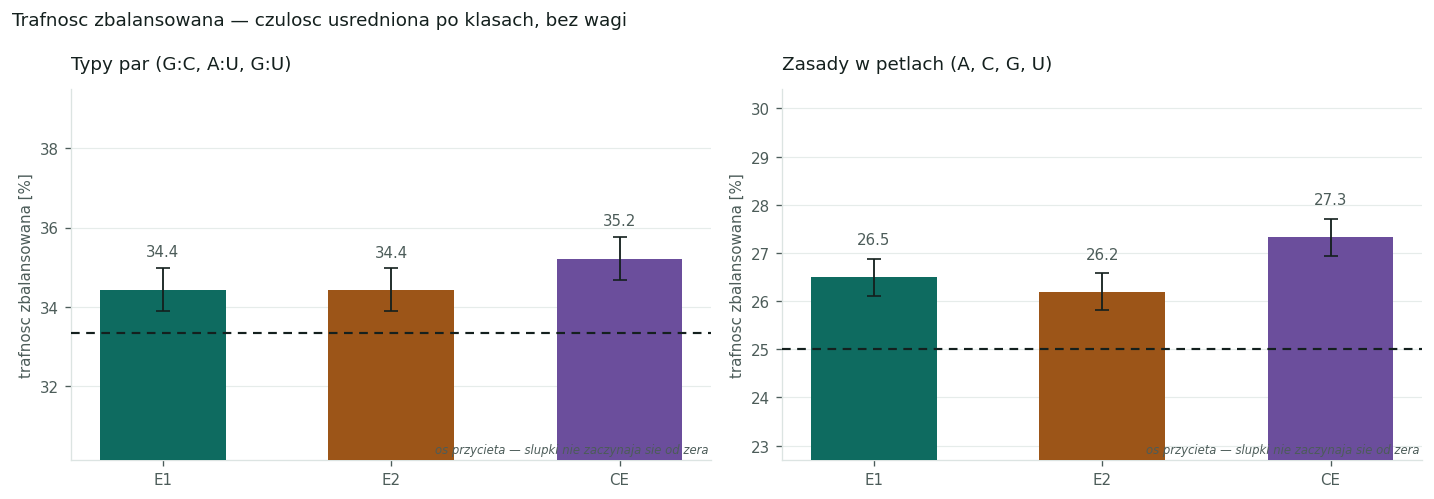

In [4]:
nat = d[(d.zbior == "test") & (d.dlugosc == "<= 200 nt")]

# BEZ BASELINE'U. Kazdy predyktor niezalezny od wejscia — a taki jest baseline — dostaje dokladnie
# 1/k, czyli lezy na linii odniesienia. Slupek nie wnosilby tu nic ponad nia. Na pozostalych
# wykresach baseline zostaje, bo tam linia oznacza co innego niz on.
MODELE_LAB = [l for l in LAB if l != "baseline"]

fig, axs = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, kol, poziom, tyt in ((axs[0], "zbal_par", LOSOWO_PAR, "Typy par (G:C, A:U, G:U)"),
                             (axs[1], "zbal_zasady", LOSOWO_ZAS, "Zasady w petlach (A, C, G, U)")):
    v = [float(nat[nat.etykieta == l][kol].iloc[0]) for l in MODELE_LAB]
    # Was = odchylenie POJEDYNCZEGO przebiegu. Slupki rozniace sie mniej niz 2*s*sqrt(2)
    # sa nierozroznialne — to wiecej niz zachodzenie wasow na siebie.
    b = ax.bar(range(len(MODELE_LAB)), v, 0.55, color=[KOL[l] for l in MODELE_LAB], zorder=3,
               yerr=SIGMA.get(kol), capsize=4, ecolor=INK, error_kw={"lw": 1.1, "zorder": 5})
    for r, vv in zip(b, v):
        ax.text(r.get_x() + r.get_width() / 2, vv + SIGMA.get(kol, 0) + 0.3, f"{vv:.1f}",
                ha="center", fontsize=9, color=INK2)
    ax.text(0.995, 0.02, "os przycieta — slupki nie zaczynaja sie od zera",
            transform=ax.transAxes, ha="right", fontsize=7, color=INK2, style="italic")
    # Linia odniesienia: poziom losowy, czyli 1/3 dla typow par i 1/4 dla zasad.
    ax.axhline(poziom, color=INK, lw=1.3, ls=(0, (4, 3)), zorder=4)
    ax.set_xticks(range(len(MODELE_LAB)))
    ax.set_xticklabels(MODELE_LAB, fontsize=9)
    # OS PRZYCIETA. Was ma dlugosc 0,167, a slupki stoja na wysokosci ~35 — na osi od zera
    # bylby cienszy niz linia i caly pomiar szumu bylby niewidoczny. Dolna granica to poziom
    # losowy, ktory i tak jest wlasciwym punktem odniesienia: liczy sie odleglosc OD NIEGO,
    # a nie dlugosc slupka.
    s_ = SIGMA.get(kol, 0)
    ax.set_ylim(poziom - 6 * s_, max(v) + 8 * s_)
    styl(ax, tyt, "trafnosc zbalansowana [%]")
fig.suptitle("Trafnosc zbalansowana — czulosc usredniona po klasach, bez wagi",
             color=INK, fontsize=11, x=0.008, ha="left")
fig.tight_layout()

## 2. Czułość i specyficzność osobno dla każdej klasy

Dwie miary, które trzeba czytać razem, bo dopiero razem wykrywają **nadprodukcję jednej klasy**.

```
czulosc        z tych, ktore NAPRAWDE sa klasy c, ile model rozpoznal
specyficznosc  z tych, ktore NIE sa klasy c, ilu model NIE wrzucil do c
```

Predyktor „zawsze G:C" ma czułość G:C równą 100% i specyficzność G:C równą **zeru** — rozpoznaje
wszystkie prawdziwe G:C, ale za cenę wrzucenia do nich całej reszty. Sama czułość tego nie pokaże.

Baseline losuje jednostajnie, więc jego czułość wynosi 1/3 dla każdego typu pary i 1/4 dla każdej
zasady. Jest przez to płaski i stanowi naturalne odniesienie: **wszystko, co nie odstaje od niego,
nie skorzystało z wejścia**.

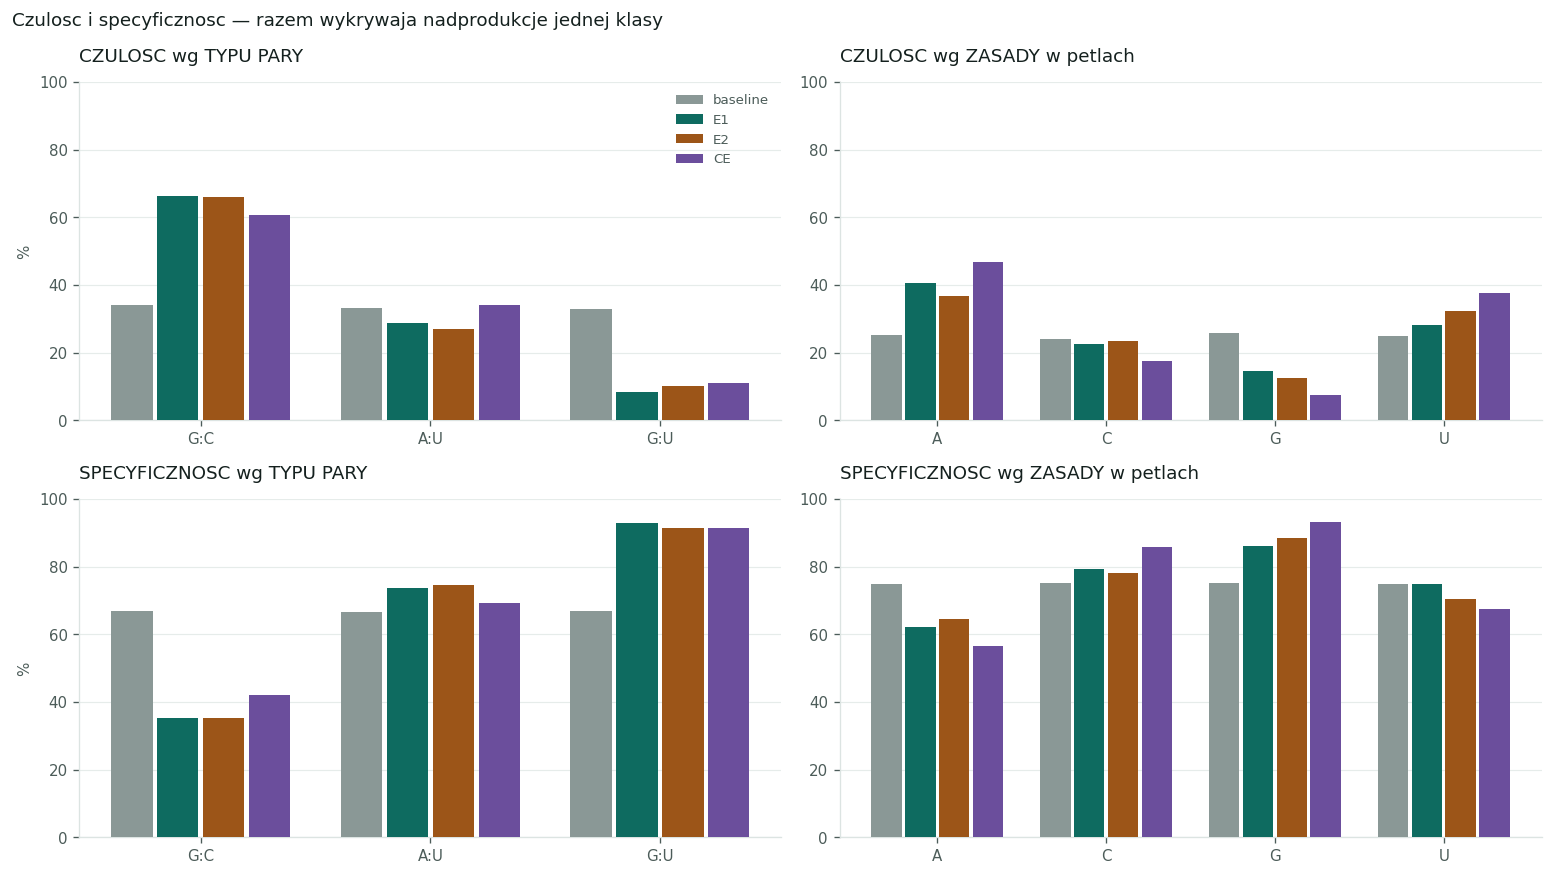

In [5]:
# Gorny rzad: czulosc. Dolny: specyficznosc. Bez linii odniesienia — poziom 1/k dotyczy SREDNIEJ
# po klasach, a nie pojedynczej klasy, wiec tutaj bylby mylacy. Odniesieniem jest slupek baseline'u.
GRUPY = ([("GC", "G:C"), ("AU", "A:U"), ("GU", "G:U")],
         [("petle_A", "A"), ("petle_C", "C"), ("petle_G", "G"), ("petle_U", "U")])

fig, axs = plt.subplots(2, 2, figsize=(13, 7.4))
for wiersz, (przedrostek, nazwa) in enumerate((("recall", "CZULOSC"), ("spec", "SPECYFICZNOSC"))):
    for kol, (grupa, co) in enumerate(zip(GRUPY, ("wg TYPU PARY", "wg ZASADY w petlach"))):
        ax = axs[wiersz][kol]
        x = np.arange(len(grupa))
        w = 0.8 / len(LAB)
        for k, l in enumerate(LAB):
            r = nat[nat.etykieta == l]
            v = [float(r[f"{przedrostek}_{c}"].iloc[0]) for c, _ in grupa]
            ax.bar(x + (k - (len(LAB) - 1) / 2) * w, v, w * 0.9, color=KOL[l],
                   label=l if (wiersz == 0 and kol == 0) else None, zorder=3)
        ax.set_xticks(x)
        ax.set_xticklabels([e for _, e in grupa], fontsize=10)
        ax.set_ylim(0, 100)
        styl(ax, f"{nazwa} {co}", "%" if kol == 0 else "")
axs[0][0].legend(frameon=False, fontsize=8, labelcolor=INK2)
fig.suptitle("Czulosc i specyficznosc — razem wykrywaja nadprodukcje jednej klasy",
             color=INK, fontsize=11, x=0.008, ha="left")
fig.tight_layout()

## 3. Identyczność sekwencyjna

Ile pozycji ma tę samą zasadę co referencja (lewy panel) i ile par ma trafiony typ (prawy).

Miara łatwiejsza do odczytania niż trafność zbalansowana, ale trzeba pamiętać o jej wadzie: **rośnie,
gdy model wskazuje klasę najczęstszą**, nawet jeśli robi to zawsze. Dlatego rozstrzygamy trafnością
zbalansowaną z sekcji 1, a tę traktujemy jako uzupełnienie. Baseline jest tu punktem odniesienia.

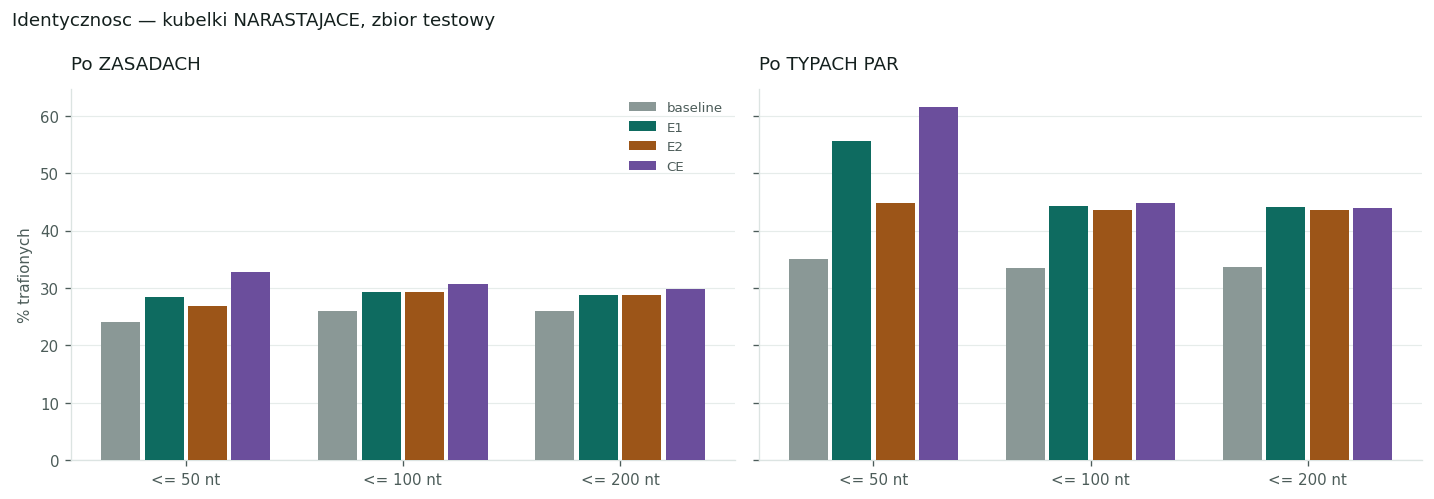

In [6]:
testy = d[d.zbior == "test"]
kubelki = list(dict.fromkeys(testy.dlugosc))

fig, axs = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
x = np.arange(len(kubelki))
w = 0.8 / len(LAB)
for ax, kol, tyt in ((axs[0], "identycznosc_nt", "Po ZASADACH"),
                     (axs[1], "identycznosc_par", "Po TYPACH PAR")):
    for k, l in enumerate(LAB):
        v = [float(testy[(testy.etykieta == l) & (testy.dlugosc == kk)][kol].iloc[0])
             for kk in kubelki]
        ax.bar(x + (k - (len(LAB) - 1) / 2) * w, v, w * 0.9, color=KOL[l],
               label=l if ax is axs[0] else None, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(kubelki, fontsize=9)
    styl(ax, tyt, "% trafionych" if ax is axs[0] else "")
axs[0].legend(frameon=False, fontsize=8, labelcolor=INK2)
fig.suptitle("Identycznosc — kubelki NARASTAJACE, zbior testowy",
             color=INK, fontsize=11, x=0.008, ha="left")
fig.tight_layout()

## 4. Energia

`dE/nt` mowi, o ile stabilniej nasza sekwencja trzyma zadana strukture niz sekwencja referencyjna; ujemne
znaczy stabilniej. Uwaga przy odczycie: **bardzo ujemne wartosci to sygnal degeneracji**, a nie sukces.
Sekwencje zlozone z samych par G:C maja srednio -0,59 kcal/mol/nt, a prawdziwe RNA tylko -0,28 —
natura celowo nie schodzi do minimum energii, bo czasteczka maksymalnie stabilna zwijalaby sie
rownie chetnie na wiele sposobow.

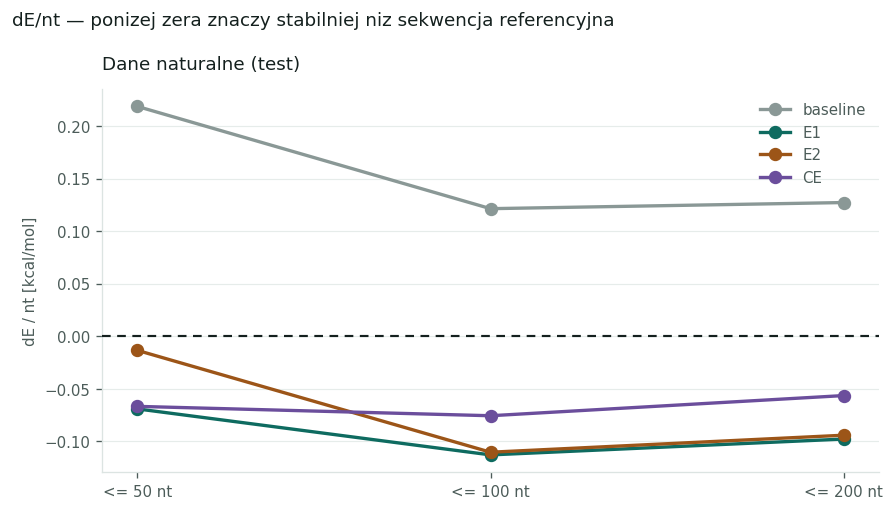

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4.3))
czesc = d[d.zbior == "test"]
kk = list(dict.fromkeys(czesc.dlugosc))
for l in LAB:
    v = [float(czesc[(czesc.etykieta == l) & (czesc.dlugosc == k)].dE_nt.iloc[0]) for k in kk]
    ax.plot(range(len(kk)), v, "-o", color=KOL[l], lw=2, ms=7, label=l, zorder=3)
ax.axhline(0, color=INK, lw=1.3, ls=(0, (4, 3)), zorder=4)
ax.set_xticks(range(len(kk)))
ax.set_xticklabels(kk, fontsize=9)
styl(ax, "Dane naturalne (test)", "dE / nt [kcal/mol]")
ax.legend(frameon=False, fontsize=9, labelcolor=INK2)
fig.suptitle("dE/nt — ponizej zera znaczy stabilniej niz sekwencja referencyjna",
             color=INK, fontsize=11, x=0.008, ha="left")
fig.tight_layout()

## 5. Co model faktycznie wypisuje

Do tej pory patrzyliśmy na miary. Teraz generujemy sekwencje i oglądamy ich skład. **Dekodowanie musi
być takie samo jak w treningu danego modelu**, inaczej porównywalibyśmy co innego niż raportujemy.

Ta sekcja wymaga GPU i checkpointów.

In [8]:
import torch
import random

from src.evaluate import wczytaj_model, generuj
from src.dataset import losowa_kanoniczna

dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
baza = wczytaj()
idx = wczytaj_split("rodzinowy")["test"]
S = baza.secondary_structure.iloc[idx].tolist()
Q = baza.sequence.iloc[idx].tolist()

# (etykieta, checkpoint, dekodowanie) — dekodowanie MUSI zgadzac sie z trybem treningu.
MODELE = [("E1", "checkpoints/e1_sklad_tv.pt", "argmax"),
          ("E2", "checkpoints/e2_sklad_progi.pt", "argmax"),
          ("CE", "checkpoints/ce_sama_ce.pt", "argmax")]

# Baseline generujemy tak samo jak reszte, zeby byl na wykresach skladu obok modeli.
random.seed(0)
gen = {"baseline": [losowa_kanoniczna(t) for t in S]}
for lab, ck, dek in MODELE:
    if (Path.cwd().parent / ck).exists():
        m, _ = wczytaj_model(ck, dev)
        gen[lab] = generuj(m, S, dev, dekodowanie=dek, seed=0)
        del m
        torch.cuda.empty_cache()
        print(f"{lab:<9} {dek}")
    else:
        print(f"brak {ck}")
print(f"wygenerowano dla {len(S)} struktur testowych")

C:\Users\janle\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


E1        argmax


E2        argmax


CE        argmax
wygenerowano dla 728 struktur testowych


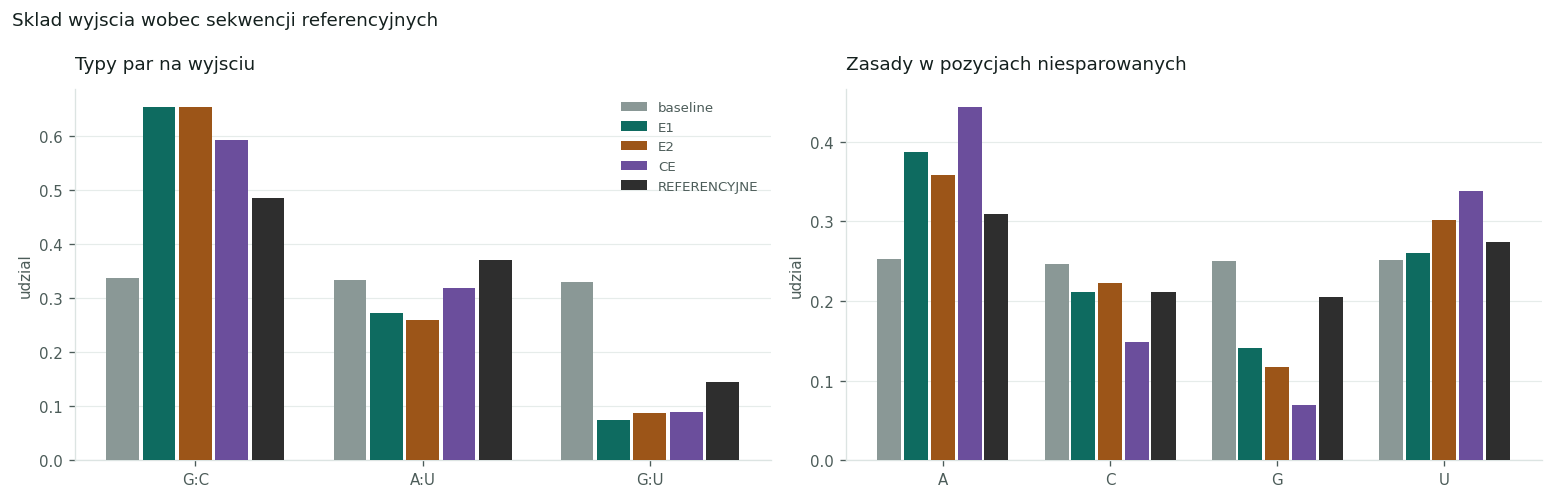

In [9]:
zrodla_m = list(gen.items()) + [("REFERENCYJNE", Q)]
kolory_m = {**KOL, "REFERENCYJNE": "#2E2E2E"}

fig, axs = plt.subplots(1, 2, figsize=(13, 4.2))
x = np.arange(3)
w = 0.8 / len(zrodla_m)
for k, (l, g) in enumerate(zrodla_m):
    t = typy_par(S, g)
    tot = sum(t.values()) or 1
    v = [t[kk] / tot for kk in ("G:C", "A:U", "G:U")]
    axs[0].bar(x + (k - (len(zrodla_m) - 1) / 2) * w, v, w * 0.9,
               color=kolory_m.get(l, C4), label=l, zorder=3)
axs[0].set_xticks(x)
axs[0].set_xticklabels(["G:C", "A:U", "G:U"], fontsize=10)
styl(axs[0], "Typy par na wyjsciu", "udzial")
axs[0].legend(frameon=False, fontsize=8, labelcolor=INK2)

x = np.arange(4)
petle = ["spinka", "wybrzuszenie", "multipetla", "regiony-zewnetrzne"]
for k, (l, g) in enumerate(zrodla_m):
    c = sklad_motywy(S, g)
    lacz = Counter()
    for m_ in petle:
        lacz.update(c[m_])
    tot = sum(lacz.values()) or 1
    axs[1].bar(x + (k - (len(zrodla_m) - 1) / 2) * w, [lacz[b] / tot for b in BASES], w * 0.9,
               color=kolory_m.get(l, C4), zorder=3)
axs[1].set_xticks(x)
axs[1].set_xticklabels(BASES, fontsize=10)
styl(axs[1], "Zasady w pozycjach niesparowanych", "udzial")
fig.suptitle("Sklad wyjscia wobec sekwencji referencyjnych",
             color=INK, fontsize=11, x=0.008, ha="left")
fig.tight_layout()

## 6. Degeneracja wg motywu

Najostrzejszy obraz problemu. Jeśli model wypełnia wszystkie typy pętli tą samą zasadą, znaczy to, że
nie rozróżnia motywów — a to była cała nadzieja związana z transformerem patrzącym holistycznie.

UDZIAL ADENINY w pozycjach niesparowanych

motyw                   pozycji      baseline            E1            E2            CE  REFERENCYJNE


spinka                     9376         0.251         0.376         0.339         0.381         0.286


wybrzuszenie              12636         0.254         0.406         0.399         0.492         0.313


multipetla                 1217         0.243         0.505         0.353         0.495         0.439


regiony-zewnetrzne         7322         0.253         0.350         0.314         0.434         0.311


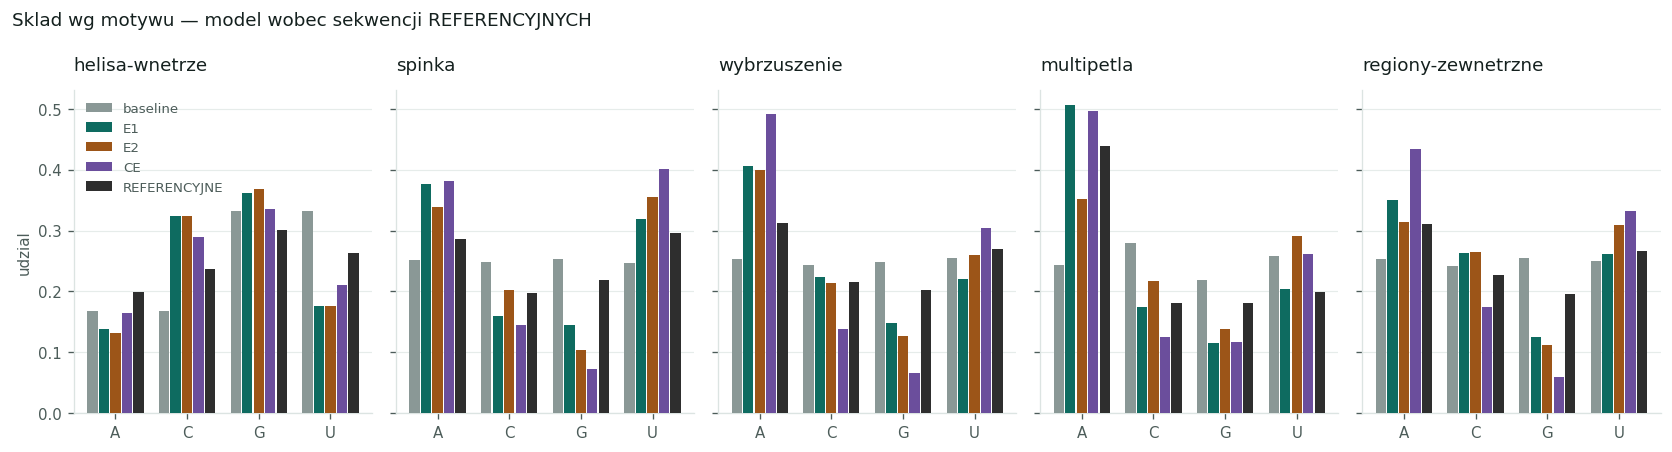

In [10]:
pokaz = ["helisa-wnetrze", "spinka", "wybrzuszenie", "multipetla", "regiony-zewnetrzne"]
fig, axs = plt.subplots(1, len(pokaz), figsize=(14, 3.8), sharey=True)
x = np.arange(4)
w = 0.8 / len(zrodla_m)
for ax, m_ in zip(axs, pokaz):
    for k, (l, g) in enumerate(zrodla_m):
        c = sklad_motywy(S, g)[m_]
        t = sum(c.values()) or 1
        ax.bar(x + (k - (len(zrodla_m) - 1) / 2) * w, [c[b] / t for b in BASES], w * 0.9,
               color=kolory_m.get(l, C4), label=l if m_ == pokaz[0] else None, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(BASES, fontsize=9)
    styl(ax, m_, "udzial" if m_ == pokaz[0] else "")
axs[0].legend(frameon=False, fontsize=8, labelcolor=INK2)
fig.suptitle("Sklad wg motywu — model wobec sekwencji REFERENCYJNYCH",
             color=INK, fontsize=11, x=0.008, ha="left")
fig.tight_layout()

print("UDZIAL ADENINY w pozycjach niesparowanych\n")
print(f"{'motyw':<22}{'pozycji':>9}" + "".join(f"{l:>14}" for l, _ in zrodla_m))
for mot in ["spinka", "wybrzuszenie", "multipetla", "regiony-zewnetrzne"]:
    n = sum(sklad_motywy(S, Q)[mot].values())
    kom = ""
    for l, g in zrodla_m:
        c = sklad_motywy(S, g)[mot]
        t = sum(c.values()) or 1
        kom += f"{c['A'] / t:>14.3f}"
    print(f"{mot:<22}{n:>9}" + kom)

---

# Warianty z wazona cross-entropia — przygotowanie

`E1W`, `E2W` i `CEW` to te same trzy konfiguracje co wyzej, ale z **CE wazona odwrotnie do czestosci
klas**. Wagi `1/czestosc` liczone na TRENINGU, znormalizowane do sredniej 1, wiec skala straty sie
nie zmienia.

**Po co.** Zwykla CE optymalizuje trafienia wazone liczebnoscia, wiec klasa G:C (60% par
treningowych) wnosi do gradientu osiem razy wiecej niz G:U (5%). Modelowi oplaca sie wtedy zbudowac
wokol klasy najczestszej. Wagi to usuwaja — sa **odpowiednikiem trafnosci zbalansowanej po stronie
uczenia**, tak jak `zbal_par` jest nim po stronie pomiaru.

Nie pokazujemy ich w osobnym zestawie wykresow. Wazenie ma sens wylacznie **w odniesieniu do swojego
odpowiednika bez wazenia**, wiec caly material jest w zestawie III, gdzie kazda para stoi obok
siebie i rozni ja dokladnie jedna rzecz. Ponizsze dwie komorki tylko przygotowuja dane.


In [11]:
# Osobny slownik i osobna paleta, zeby ZESTAW I pozostal nietkniety.
PLIKI_W = {
    "baseline": "baseline_test.csv",
    "E1W":      "e1w_test.csv",
    "E2W":      "e2w_test.csv",
    "CEW":      "cew_test.csv",
}

kawalki_w = []
for lab, p in PLIKI_W.items():
    f = ANALIZA / p
    if f.exists():
        x = pd.read_csv(f)
        x["etykieta"] = lab
        kawalki_w.append(x)
    else:
        print(f"brak {p} — uruchom odpowiedni eksperyment")

dw = pd.concat(kawalki_w, ignore_index=True) if kawalki_w else pd.DataFrame()
LAB_W = [l for l in PLIKI_W if l in set(dw.etykieta)] if len(dw) else []
# Te same kolory co odpowiedniki z zestawu I: baseline szary, kara TV zielona, progi brazowe,
# ablacja fioletowa. Dzieki temu oba zestawy czyta sie tym samym kluczem.
KOL_W = {"baseline": C4, "E1W": C1, "E2W": C2, "CEW": C3}

display(dw[(dw.zbior == "test") & (dw.dlugosc == "<= 200 nt")][KOLUMNY]
        .set_index("etykieta").round(3))
print(f"poziom losowy:  zbal_par {LOSOWO_PAR:.1f}%   zbal_zas {LOSOWO_ZAS:.1f}%")

,n,identycznosc_nt,identycznosc_par,zbal_par,zbal_zasady,dE_nt,kara_wlasna
etykieta,,,,,,,
baseline,728,25.948,33.699,33.460,25.031,0.127,NaN
E1W,728,28.111,40.677,35.300,26.419,0.009,0.32
E2W,728,27.822,38.723,35.413,26.669,0.025,0.13
CEW,728,27.616,38.005,35.700,27.262,0.121,NaN


poziom losowy:  zbal_par 33.3%   zbal_zas 25.0%


In [12]:
# Sekwencje dla wariantow wazonych. `gen`, `S` i `Q` z pierwszej czesci zostaja nietkniete.
MODELE_W_CK = [("E1W", "checkpoints/e1w_wazona_ce.pt"),
               ("E2W", "checkpoints/e2w_wazona_ce.pt"),
               ("CEW", "checkpoints/cew_wazona_ce.pt")]

genw = {"baseline": gen["baseline"]}   # ten sam baseline co wyzej
for lab, ck in MODELE_W_CK:
    if (Path.cwd().parent / ck).exists():
        mw, _ = wczytaj_model(ck, dev)
        genw[lab] = generuj(mw, S, dev, dekodowanie="argmax")
        del mw
        torch.cuda.empty_cache()
        print(f"{lab:<9} argmax")
    else:
        print(f"brak {ck}")

C:\Users\janle\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


E1W       argmax


E2W       argmax


CEW       argmax


---

# ZESTAW II — co robi samo wazenie klas

Tu kazda konfiguracja stoi obok swojego odpowiednika, w **parach**, w ktorych jedyna
roznica to wazenie CE:

```
E1  <->  E1W     kara TV za sklad,        bez wagi / z waga
E2  <->  E2W     kara progowa promotora,  bez wagi / z waga
CE  <->  CEW     bez kar,                 bez wagi / z waga
```

Wszystko inne — dane, podzial, architektura, wagi kar, dekodowanie, kryterium wyboru epoki, liczba
epok — jest w obrebie pary identyczne. **Kazda roznica wewnatrz slupka podwojnego pochodzi wiec
wylacznie od wazenia**, i to jest jedyny uklad w calym notatniku, ktory pozwala to powiedziec.

Slupek jasny z kreskowaniem = wersja wazona. Kolor oznacza pare, tak jak w pierwszym zestawie.


In [13]:
# Laczymy wersje niewazone i wazone w jedna ramke.
PARY = [("E1", "E1W", C1), ("E2", "E2W", C2), ("CE", "CEW", C3)]

def _wiersz(tab, lab):
    r = tab[(tab.etykieta == lab) & (tab.zbior == "test") & (tab.dlugosc == "<= 200 nt")]
    return r.iloc[0] if len(r) else None

WIERSZ = {}
for a, b, _ in PARY:
    WIERSZ[a] = _wiersz(d, a)
    WIERSZ[b] = _wiersz(dw, b)
brak = [k for k, v in WIERSZ.items() if v is None]
if brak:
    print("BRAK wynikow dla:", brak, "— uruchom odpowiednie eksperymenty")

def youden(r, klasy):
    """Czulosc + specyficznosc - 1, usredniona po klasach. Poziom odniesienia = 0."""
    return sum((r[f"recall_{k}"] + r[f"spec_{k}"] - 100) for k in klasy) / len(klasy)

# Sklad wyjscia — z sekwencji wygenerowanych wyzej.
WSZ_GEN = {**{k: v for k, v in gen.items() if k != "baseline"},
           **{k: v for k, v in genw.items() if k != "baseline"}}

def _sklad(seqs):
    """Udzialy typow par (G:C, A:U, G:U) oraz zasad w pozycjach niesparowanych (A, C, G, U)."""
    t = typy_par(S, seqs)
    tp = sum(t.values()) or 1
    par = [t[k] / tp for k in ("G:C", "A:U", "G:U")]
    c = sklad_motywy(S, seqs)
    lacz = Counter()
    for m_ in ["spinka", "wybrzuszenie", "multipetla", "regiony-zewnetrzne"]:
        lacz.update(c[m_])
    tz = sum(lacz.values()) or 1
    return par, [lacz[b] / tz for b in BASES]

SKLAD = {k: _sklad(v) for k, v in WSZ_GEN.items()}
REF_PAR, REF_ZAS = _sklad(Q)

print(f"{'model':<6}{'zbal_par':>10}{'zbal_zas':>10}{'Youden par':>12}{'id_nt':>8}"
      f"{'id_par':>8}{'dE/nt':>9}{'G:C wyj':>9}{'A w petl':>10}")
for a, b, _ in PARY:
    for l in (a, b):
        r = WIERSZ[l]
        if r is None:
            continue
        print(f"{l:<6}{r.zbal_par:>9.2f}%{r.zbal_zasady:>9.2f}%"
              f"{youden(r, ('GC','AU','GU'))/100:>+12.4f}{r.identycznosc_nt:>7.2f}%"
              f"{r.identycznosc_par:>7.2f}%{r.dE_nt:>9.4f}"
              f"{SKLAD[l][0][0]:>9.3f}{SKLAD[l][1][0]:>10.3f}")
    print()
print(f"REFERENCJA{'':<44}{REF_PAR[0]:>9.3f}{REF_ZAS[0]:>10.3f}")


model   zbal_par  zbal_zas  Youden par   id_nt  id_par    dE/nt  G:C wyj  A w petl
E1        34.43%    26.49%     +0.0169  28.79%  44.18%  -0.0977    0.654     0.388
E1W       35.30%    26.42%     +0.0283  28.11%  40.68%   0.0094    0.488     0.277

E2        34.43%    26.20%     +0.0161  28.76%  43.57%  -0.0940    0.653     0.358
E2W       35.41%    26.67%     +0.0292  27.82%  38.72%   0.0246    0.488     0.237

CE        35.22%    27.33%     +0.0287  29.88%  43.98%  -0.0563    0.592     0.444
CEW       35.70%    27.26%     +0.0361  27.62%  38.00%   0.1212    0.333     0.146

REFERENCJA                                                0.484     0.309


## II.1. Wszystkie miary rozstrzygające, parami

Sześć paneli, w każdym trzy pary. Czarna linia przerywana to poziom odniesienia dla danej miary. Wąsy to odchylenie pojedynczego przebiegu; panel `identycznosc_par` ich nie ma, bo tej miary nie mierzyliśmy w powtórzeniach.

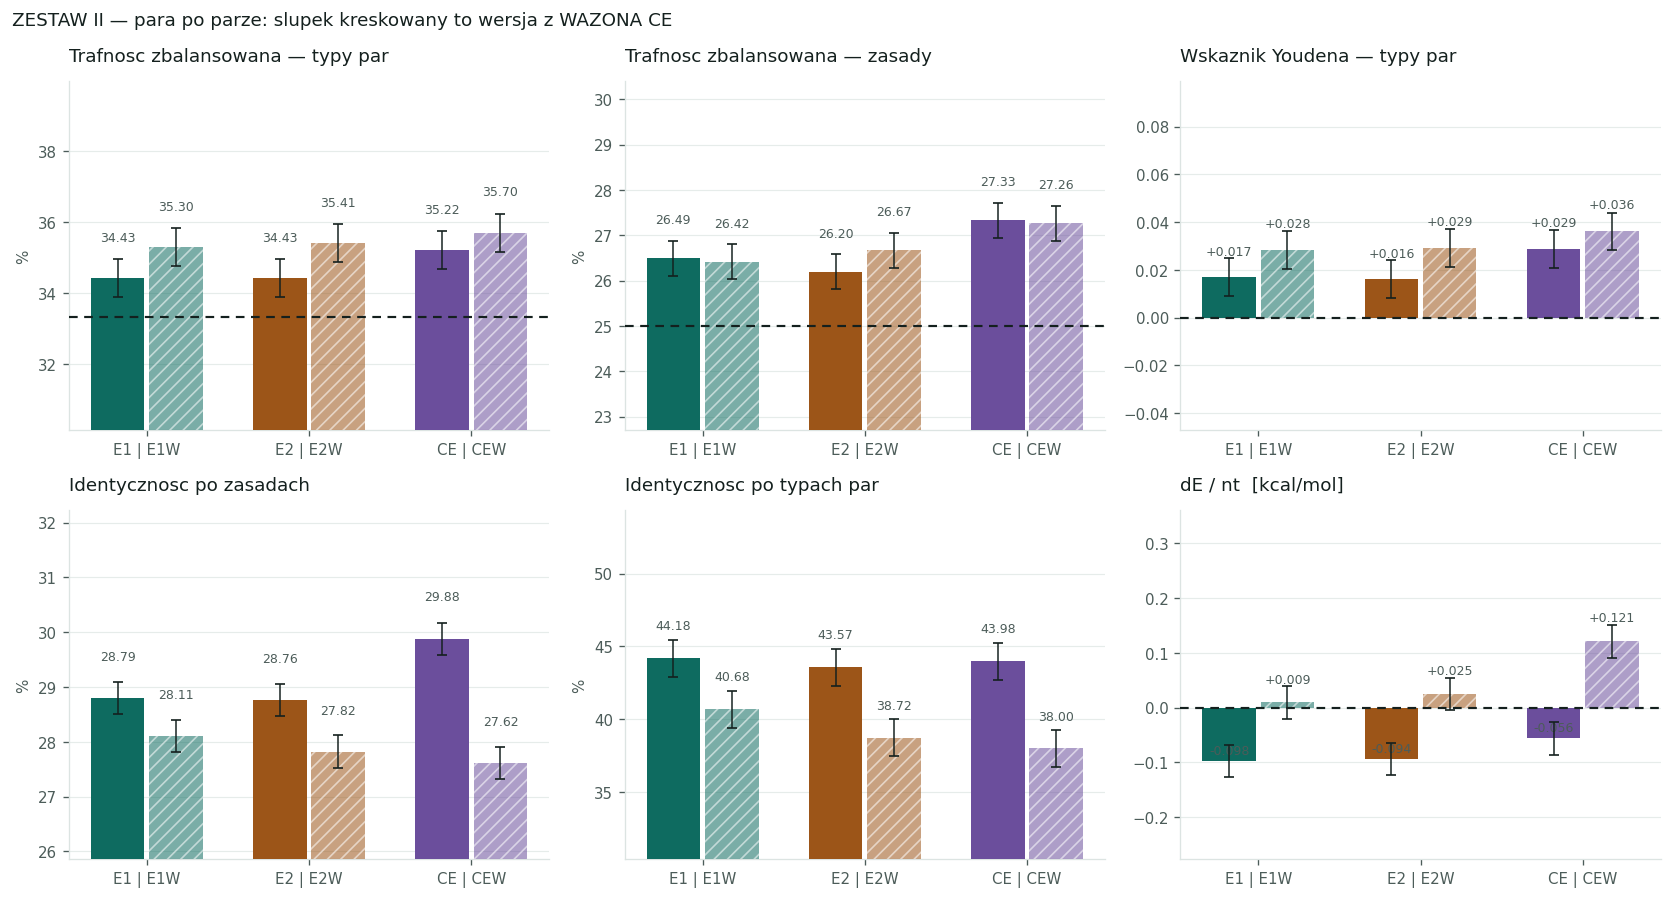

In [14]:
MIARY = [
    ("zbal_par",       "Trafnosc zbalansowana — typy par",      "%",   LOSOWO_PAR),
    ("zbal_zasady",    "Trafnosc zbalansowana — zasady",        "%",   LOSOWO_ZAS),
    ("youden_par",     "Wskaznik Youdena — typy par",           "",    0.0),
    ("identycznosc_nt", "Identycznosc po zasadach",             "%",   None),
    ("identycznosc_par", "Identycznosc po typach par",          "%",   None),
    ("dE_nt",          "dE / nt  [kcal/mol]",                   "",    0.0),
]

fig, axs = plt.subplots(2, 3, figsize=(14, 7.6))
for ax, (kol, tyt, jed, poziom) in zip(axs.ravel(), MIARY):
    x = np.arange(len(PARY))
    for k, (a, b, kolor) in enumerate(PARY):
        for j, l in enumerate((a, b)):
            r = WIERSZ[l]
            if r is None:
                continue
            v = youden(r, ("GC", "AU", "GU")) / 100 if kol == "youden_par" else float(r[kol])
            ax.bar(x[k] + (j - 0.5) * 0.36, v, 0.33, color=kolor,
                   alpha=1.0 if j == 0 else 0.55,
                   hatch="" if j == 0 else "///", edgecolor="white", linewidth=0, zorder=3,
                   yerr=SIGMA.get(kol), capsize=3, ecolor=INK,
                   error_kw={"lw": 0.9, "zorder": 5})
            ax.text(x[k] + (j - 0.5) * 0.36, v + SIGMA.get(kol, 0) + (0.012 * abs(v) if v else 0.001),
                    f"{v:.2f}" if jed else f"{v:+.3f}", ha="center", va="bottom" if v >= 0 else "top",
                    fontsize=7.5, color=INK2)
    if poziom is not None:
        ax.axhline(poziom, color=INK, lw=1.3, ls=(0, (4, 3)), zorder=4)
    # Os przycieta z tego samego powodu co w zestawie I — inaczej wasow nie widac.
    s_ = SIGMA.get(kol)
    if s_:
        w_ = [youden(WIERSZ[l], ("GC", "AU", "GU")) / 100 if kol == "youden_par"
              else float(WIERSZ[l][kol]) for p_ in PARY for l in p_[:2] if WIERSZ[l] is not None]
        dol = min(w_ + ([poziom] if poziom is not None else []))
        ax.set_ylim(dol - 6 * s_, max(w_) + 8 * s_)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{a} | {b}" for a, b, _ in PARY], fontsize=9)
    styl(ax, tyt, jed)
fig.suptitle("ZESTAW II — para po parze: slupek kreskowany to wersja z WAZONA CE",
             color=INK, fontsize=11, x=0.008, ha="left")
fig.tight_layout()

## II.2. Mechanizm — czułość i specyficzność klasa po klasie

Tu widać, *skąd* bierze się zmiana: ważenie odbiera czułość klasie najczęstszej i oddaje ją rzadkim.

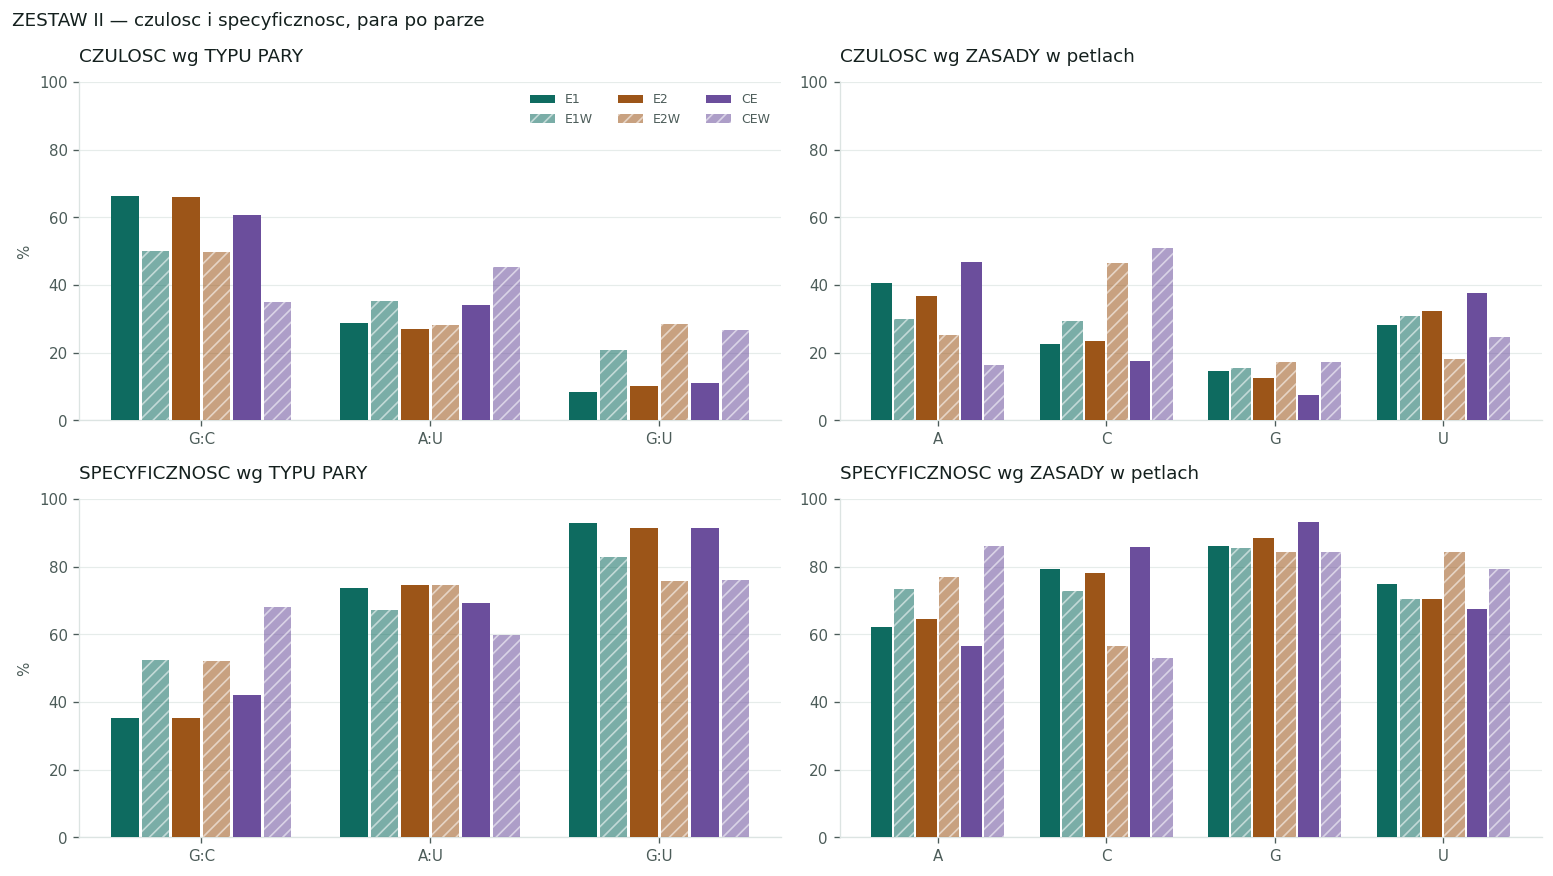

In [15]:
KLASY_P = [("GC", "G:C"), ("AU", "A:U"), ("GU", "G:U")]
KLASY_Z = [("petle_A", "A"), ("petle_C", "C"), ("petle_G", "G"), ("petle_U", "U")]

fig, axs = plt.subplots(2, 2, figsize=(13, 7.4))
for w, (przed, nazwa) in enumerate((("recall", "CZULOSC"), ("spec", "SPECYFICZNOSC"))):
    for kk, (grupa, cco) in enumerate(zip((KLASY_P, KLASY_Z),
                                          ("wg TYPU PARY", "wg ZASADY w petlach"))):
        ax = axs[w][kk]
        x = np.arange(len(grupa))
        szer = 0.8 / (2 * len(PARY))
        for k, (a, b, kolor) in enumerate(PARY):
            for j, l in enumerate((a, b)):
                r = WIERSZ[l]
                if r is None:
                    continue
                v = [float(r[f"{przed}_{c}"]) for c, _ in grupa]
                poz = x + (2 * k + j - (2 * len(PARY) - 1) / 2) * szer
                ax.bar(poz, v, szer * 0.9, color=kolor, alpha=1.0 if j == 0 else 0.55,
                       hatch="" if j == 0 else "///", edgecolor="white", linewidth=0,
                       label=l if (w == 0 and kk == 0) else None, zorder=3)
        ax.set_xticks(x)
        ax.set_xticklabels([e for _, e in grupa], fontsize=10)
        ax.set_ylim(0, 100)
        styl(ax, f"{nazwa} {cco}", "%" if kk == 0 else "")
axs[0][0].legend(frameon=False, fontsize=7.5, labelcolor=INK2, ncol=3)
fig.suptitle("ZESTAW II — czulosc i specyficznosc, para po parze",
             color=INK, fontsize=11, x=0.008, ha="left")
fig.tight_layout()

## II.3. Skład wyjścia, para po parze

Czarna linia przerywana w każdej kolumnie to wartość w sekwencjach referencyjnych. Tu widać, że
ważenie przesuwa skład **w drugą stronę** niż kara za skład.

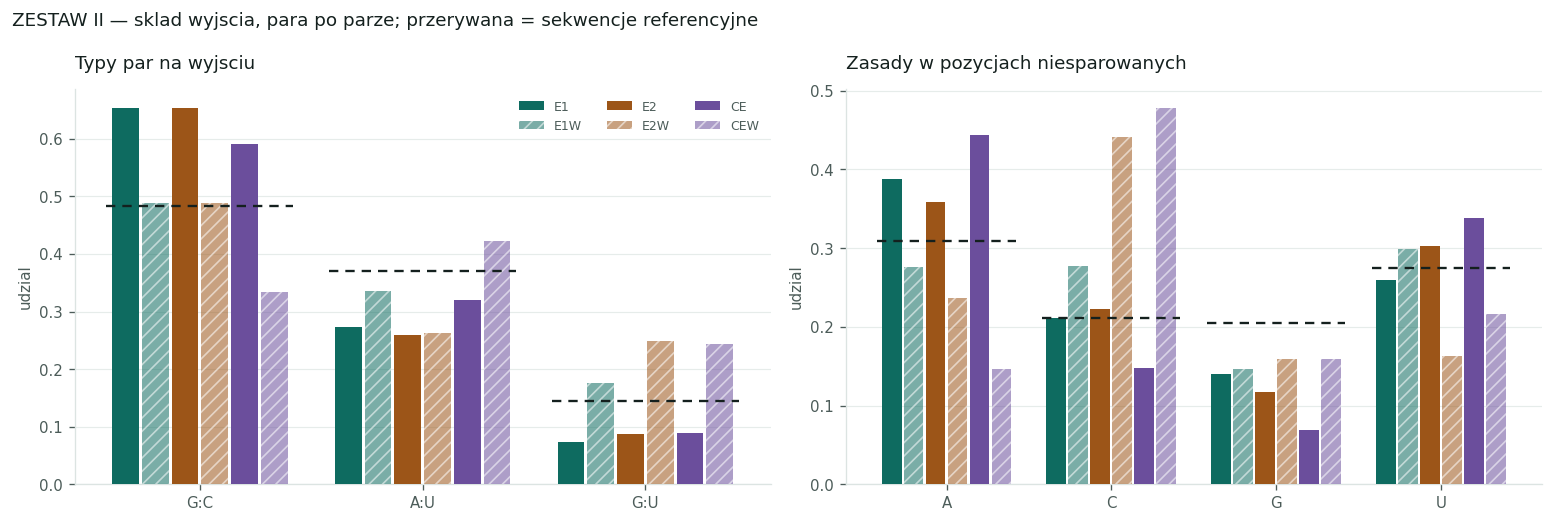

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.4))
for ax, etyk, ref, idx in ((axs[0], ["G:C", "A:U", "G:U"], REF_PAR, 0),
                           (axs[1], BASES, REF_ZAS, 1)):
    x = np.arange(len(etyk))
    szer = 0.8 / (2 * len(PARY))
    for k, (a, b, kolor) in enumerate(PARY):
        for j, l in enumerate((a, b)):
            if l not in SKLAD:
                continue
            poz = x + (2 * k + j - (2 * len(PARY) - 1) / 2) * szer
            ax.bar(poz, SKLAD[l][idx], szer * 0.9, color=kolor, alpha=1.0 if j == 0 else 0.55,
                   hatch="" if j == 0 else "///", edgecolor="white", linewidth=0,
                   label=l if idx == 0 else None, zorder=3)
    for i, v in enumerate(ref):
        ax.plot([i - 0.42, i + 0.42], [v, v], color=INK, lw=1.4, ls=(0, (4, 3)), zorder=5)
    ax.set_xticks(x)
    ax.set_xticklabels(etyk, fontsize=10)
    styl(ax, "Typy par na wyjsciu" if idx == 0 else "Zasady w pozycjach niesparowanych", "udzial")
axs[0].legend(frameon=False, fontsize=7.5, labelcolor=INK2, ncol=3)
fig.suptitle("ZESTAW II — sklad wyjscia, para po parze; przerywana = sekwencje referencyjne",
             color=INK, fontsize=11, x=0.008, ha="left")
fig.tight_layout()

---

# ZESTAW III — rozkład kar na składniki

`E1` ma trzy kary i wypada **gorzej** niż `CE`, które nie ma żadnej. Tylko że te dwa przebiegi
różnią się trzema rzeczami naraz, więc z samego ich zestawienia nie wynika, która za to odpowiada.

`E3` rozcina to na dwa kroki, z których każdy zmienia dokładnie jedną rzecz:

```
E1 -> E3    zdejmujemy KARE ZA SKLAD          (zostaja energia i parowania)
E3 -> CE    zdejmujemy ENERGIE i PAROWANIA    (nie zostaje nic)
```

`E3` nie jest kandydatem na model — to **kontrola**. Nie stoi w zestawie I obok E1, E2 i CE,
bo odpowiada na inne pytanie niż one.

Werdykty poniżej pochodzą z porównań **parowanych**: różnicę liczymy w obrębie ziarna, bo obie
konfiguracje przeszły przez te same trzy ziarna. To znosi szum wspólny obu przebiegom i jest
mocniejsze niż zestawianie samych średnich.


In [17]:
d3 = None
if (ANALIZA / "e3_test.csv").exists():
    d3 = pd.read_csv(ANALIZA / "e3_test.csv")
    d3["etykieta"] = "E3"
    WIERSZ["E3"] = d3[(d3.zbior == "test") & (d3.dlugosc == "<= 200 nt")].iloc[0]

    ck3 = "checkpoints/e3_bez_skladu.pt"
    if (Path.cwd().parent / ck3).exists():
        m3, _ = wczytaj_model(ck3, dev)
        gen["E3"] = generuj(m3, S, dev, dekodowanie="argmax", seed=0)
        SKLAD["E3"] = _sklad(gen["E3"])
        del m3
        torch.cuda.empty_cache()

    TROJKA = ["E1", "E3", "CE"]
    print(f"{'model':<6}{'sklad':<8}{'ener+par':<10}{'zbal_par':>10}{'Youden':>10}"
          f"{'id_nt':>8}{'dE/nt':>9}{'G:C wyj':>9}")
    for l, ma_sklad, ma_ep in (("E1", "tak", "tak"), ("E3", "—", "tak"), ("CE", "—", "—")):
        r = WIERSZ[l]
        print(f"{l:<6}{ma_sklad:<8}{ma_ep:<10}{r.zbal_par:>9.2f}%"
              f"{youden(r, ('GC','AU','GU'))/100:>+10.4f}{r.identycznosc_nt:>7.2f}%"
              f"{r.dE_nt:>9.4f}{SKLAD[l][0][0]:>9.3f}")
    print(f"{'REFERENCJA':<61}{REF_PAR[0]:>9.3f}")
    print(f"\nISTOTNOSC (TEST, porownania parowane, 3 ziarna)\n")
    parami("E1", "E3")
    parami("E3", "CE")
else:
    print("brak e3_test.csv — uruchom  python run.py E3")


C:\Users\janle\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


model sklad   ener+par    zbal_par    Youden   id_nt    dE/nt  G:C wyj
E1    tak     tak           34.43%   +0.0169  28.79%  -0.0977    0.654
E3    —       tak           34.66%   +0.0183  29.44%  -0.0997    0.647
CE    —       —             35.22%   +0.0287  29.88%  -0.0563    0.592
REFERENCJA                                                       0.484

ISTOTNOSC (TEST, porownania parowane, 3 ziarna)

  E1 -> E3   zbal_par          +0.7413   prog 1.5130   znaki 2/3   w szumie
  E1 -> E3   youden_par        +0.0113   prog 0.0223   znaki 2/3   w szumie
  E1 -> E3   identycznosc_nt   +1.1380   prog 0.8304   znaki 3/3   REALNA
  E1 -> E3   GC_wyjscie        +0.0624   prog 0.1269   znaki 3/3   zgodny kierunek
  E1 -> E3   G_petle           -0.0393   prog 0.0914   znaki 0/3   zgodny kierunek

  E3 -> CE   zbal_par          +0.2662   prog 1.5130   znaki 3/3   zgodny kierunek
  E3 -> CE   youden_par        +0.0062   prog 0.0223   znaki 3/3   zgodny kierunek
  E3 -> CE   identycznosc_nt   -0.08

## III.1. Który krok naprawdę kosztuje

**Górny rząd — poziomy z raportowanego przebiegu.** Wąs to odchylenie pojedynczego przebiegu: tyle
wynik skacze przy samej zmianie ziarna. Osie są **przycięte** i nie zaczynają się od zera, bo inaczej
wąsy byłyby cieńsze od linii — długości słupków nie wolno przez to porównywać wzrokowo, liczy się
odległość od linii przerywanej.

**Dolny rząd — te same kroki jako różnice, uśrednione po trzech ziarnach.** `E1 → E3` czyta się
„zdjęliśmy karę za skład, oto co się zmieniło". Szare pole to próg istotności: **słupek mieszczący
się w nim jest nieodróżnialny od zera.**

Wszystko na teście, więc próg pasuje do tych właśnie liczb.


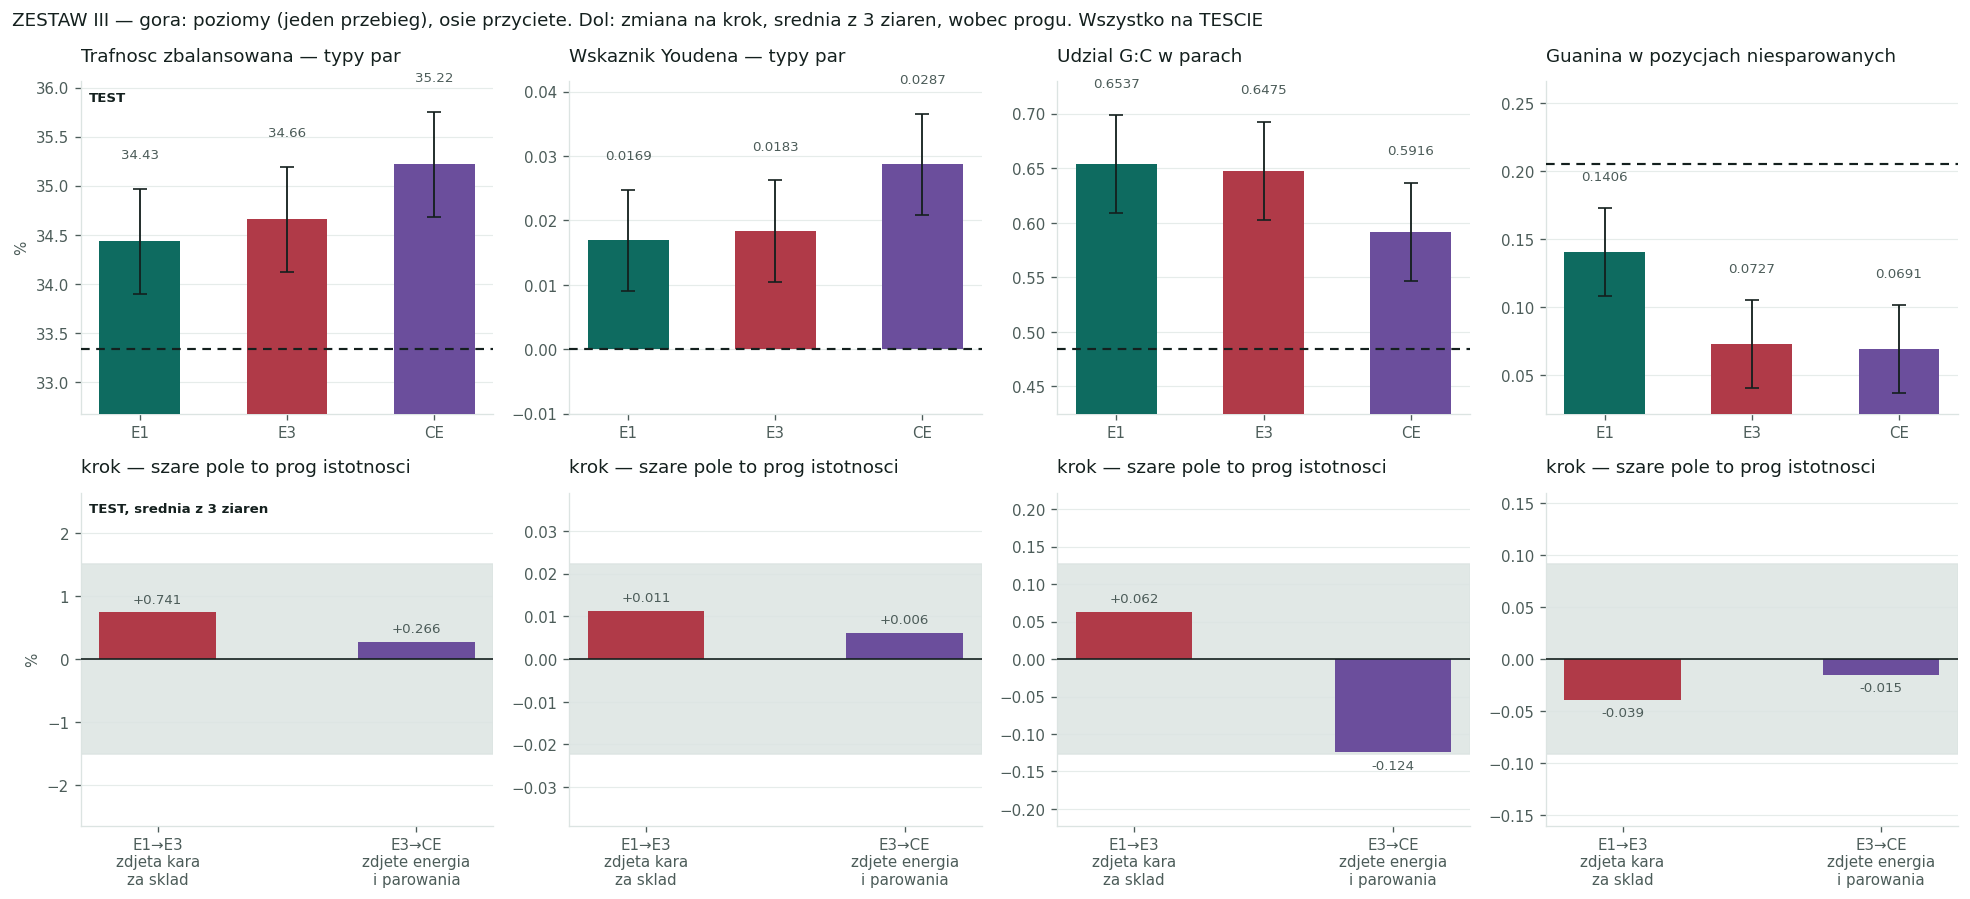

In [18]:
if d3 is not None and dsz is not None:
    TROJKA = ["E1", "E3", "CE"]
    KROKI = [("E1", "E3", "zdjeta kara\nza sklad"), ("E3", "CE", "zdjete energia\ni parowania")]
    #                                    poziomy z         odniesienie
    PANELE = [("zbal_par",   "Trafnosc zbalansowana — typy par", "%", LOSOWO_PAR),
              ("youden_par", "Wskaznik Youdena — typy par",      "",  0.0),
              ("GC_wyjscie", "Udzial G:C w parach",              "",  REF_PAR[0]),
              ("G_petle",    "Guanina w pozycjach niesparowanych", "", REF_ZAS[2])]

    def na_tescie(lab, kol):
        """Poziom raportowany — zbior TESTOWY."""
        if kol == "GC_wyjscie":
            return SKLAD[lab][0][0]
        if kol == "G_petle":
            return SKLAD[lab][1][2]          # BASES = A, C, G, U
        r = WIERSZ[lab]
        return youden(r, ("GC", "AU", "GU")) / 100 if kol == "youden_par" else float(r[kol])

    def z_powtorzen(lab, kol):
        """Srednia z trzech ziaren, na TESCIE — tam, gdzie zmierzony jest prog."""
        g = dsz[dsz.konfiguracja == lab]
        return float(g[kol].mean()) if kol in dsz.columns and not g.empty else None

    fig, axs = plt.subplots(2, 4, figsize=(16.5, 7.6))
    for k, (kol, tyt, jed, odn) in enumerate(PANELE):
        # --- gora: poziomy na TESCIE -------------------------------------
        ax = axs[0, k]
        v = [na_tescie(l, kol) for l in TROJKA]
        s = SIGMA.get(kol)                    # G_petle nie ma zmierzonego rozrzutu
        ax.bar(range(3), v, 0.55, color=[C1, C5, C3], zorder=3,
               yerr=s, capsize=4, ecolor=INK, error_kw={"lw": 1.1, "zorder": 5})
        for xx, vv in zip(range(3), v):
            ax.text(xx, vv + (s or 0) * 1.5 + (max(v) - min(v)) * 0.06,
                    f"{vv:.2f}" if jed else f"{vv:.4f}", ha="center", fontsize=8, color=INK2)
        ax.axhline(odn, color=INK, lw=1.3, ls=(0, (4, 3)), zorder=4)
        # Os przycieta — inaczej wasa (0,167 na skali do 40) po prostu nie widac.
        roz = max(v + [odn]) - min(v + [odn])
        ax.set_ylim(min(v + [odn]) - roz * 0.35, max(v + [odn]) + roz * 0.45)
        ax.set_xticks(range(3))
        ax.set_xticklabels(TROJKA, fontsize=9)
        styl(ax, tyt, jed)
        if k == 0:
            ax.text(0.02, 0.94, "TEST", transform=ax.transAxes, fontsize=8,
                    color=INK, weight="bold")

        # --- dol: kroki na WALIDACJI, tam gdzie zmierzony jest prog -------
        ax = axs[1, k]
        maw = all(z_powtorzen(l, kol) is not None for l in TROJKA)
        f = z_powtorzen if maw else na_tescie
        r = [f(b, kol) - f(a, kol) for a, b, _ in KROKI]
        prog = PROG.get(kol)
        if prog:
            ax.axhspan(-prog, prog, color=SIATKA, alpha=0.85, zorder=1)
        ax.axhline(0, color=INK, lw=1.0, zorder=4)
        ax.bar(range(2), r, 0.45, color=[C5, C3], zorder=3)
        skala = max(abs(min(r)), abs(max(r)), prog or 0)
        for xx, vv in zip(range(2), r):
            ax.text(xx, vv + (0.07 if vv >= 0 else -0.07) * skala, f"{vv:+.3f}", ha="center",
                    va="bottom" if vv >= 0 else "top", fontsize=8, color=INK2)
        ax.set_xticks(range(2))
        ax.set_xticklabels([f"{a}\u2192{b}\n{op}" for a, b, op in KROKI], fontsize=8)
        ax.set_ylim(-skala * 1.75, skala * 1.75)
        styl(ax, "krok — szare pole to prog istotnosci", jed)
        if k == 0:
            ax.text(0.02, 0.94, "TEST, srednia z 3 ziaren", transform=ax.transAxes,
                    fontsize=8, color=INK, weight="bold")
    fig.suptitle("ZESTAW III — gora: poziomy (jeden przebieg), osie przyciete. "
                 "Dol: zmiana na krok, srednia z 3 ziaren, wobec progu. Wszystko na TESCIE",
                 color=INK, fontsize=11, x=0.008, ha="left")
    fig.tight_layout()


## III.2. Co z tego wynika

**Za spadek trafności odpowiadają energia i parowania, nie kara za skład.** Krok `E3 → CE`
przekracza próg na trafności zbalansowanej i na wskaźniku Youdena; krok `E1 → E3` w obu przypadkach
zostaje pod progiem, choć kierunek jest zgodny na wszystkich trzech ziarnach. Czyli kara za skład
prawdopodobnie coś kosztuje, ale mniej, niż trzy powtórzenia potrafią zmierzyć.

**Kara za skład nie steruje udziałem G:C w parach.** Zdjęcie jej zmienia ten udział o zero, przy
niezgodnych znakach — cały ruch na G:C pochodzi z kroku `E3 → CE`, czyli z energii i parowań.
Człon energetyczny premiuje G:C jako parę najstabilniejszą i to on napędza nadmiar.

Działanie kary za skład widać gdzie indziej: w guaninie w pozycjach niesparowanych (`0,141` z karą
wobec `0,073` bez niej) i w samej wartości kary (`0,327` wobec `0,535`, przy `0,314` dla sekwencji
referencyjnych). To jedyny model, który pod względem składu pętli stoi blisko natury.
